In [33]:
!pip install opencv-python


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
!pip install pandas


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas

In [37]:
def read_file():
    img = cv2.imread(r"D:\ML PROJECTS\1\assests\dex.jpg")
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.show()
    return img

In [38]:
import os

path = r"D:\ML PROJECTS\1\assests\dex.jpg"

print("Exists:", os.path.exists(path))
img = cv2.imread(path)
print("Image:", img)

Exists: True
Image: [[[ 43  26   5]
  [ 43  26   5]
  [ 44  27   6]
  ...
  [ 54  31   9]
  [ 54  31   9]
  [ 54  31   9]]

 [[ 43  26   5]
  [ 43  26   5]
  [ 44  27   6]
  ...
  [ 54  31   9]
  [ 54  31   9]
  [ 54  31   9]]

 [[ 43  26   5]
  [ 43  26   5]
  [ 44  27   6]
  ...
  [ 54  31   9]
  [ 54  31   9]
  [ 54  31   9]]

 ...

 [[235 244 248]
  [236 245 249]
  [237 246 250]
  ...
  [198 214 221]
  [198 214 221]
  [198 214 221]]

 [[236 245 248]
  [238 247 250]
  [236 245 248]
  ...
  [200 215 224]
  [202 217 226]
  [199 214 223]]

 [[236 246 246]
  [238 248 248]
  [236 245 248]
  ...
  [200 215 224]
  [202 217 226]
  [199 214 223]]]


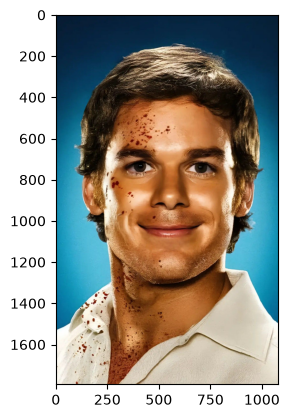

array([[[  5,  26,  43],
        [  5,  26,  43],
        [  6,  27,  44],
        ...,
        [  9,  31,  54],
        [  9,  31,  54],
        [  9,  31,  54]],

       [[  5,  26,  43],
        [  5,  26,  43],
        [  6,  27,  44],
        ...,
        [  9,  31,  54],
        [  9,  31,  54],
        [  9,  31,  54]],

       [[  5,  26,  43],
        [  5,  26,  43],
        [  6,  27,  44],
        ...,
        [  9,  31,  54],
        [  9,  31,  54],
        [  9,  31,  54]],

       ...,

       [[248, 244, 235],
        [249, 245, 236],
        [250, 246, 237],
        ...,
        [221, 214, 198],
        [221, 214, 198],
        [221, 214, 198]],

       [[248, 245, 236],
        [250, 247, 238],
        [248, 245, 236],
        ...,
        [224, 215, 200],
        [226, 217, 202],
        [223, 214, 199]],

       [[246, 246, 236],
        [248, 248, 238],
        [248, 245, 236],
        ...,
        [224, 215, 200],
        [226, 217, 202],
        [223, 214, 199]]

In [39]:
img=read_file()
og_img=img
img

EDGE MASKS - INCREASE THE EDGES

In [40]:
def edge_mask(img, line_size, blur_value):
    gray=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
    gray_blur=cv2.medianBlur(gray,blur_value)

    edges=cv2.adaptiveThreshold(gray_blur,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,line_size,3)

    return edges

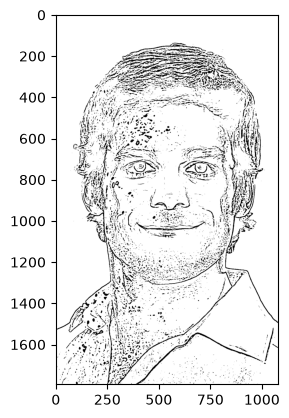

In [41]:
edges=edge_mask(img, 7, 7)
plt.imshow(edges,cmap="gray")
plt.show()

REDUCE THE COLOR PALETTE

In [42]:
def color_quantization(img,k):
    data=np.float32(img).reshape((-1,3))
    criteria =(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20 ,0.001)
    ret, label, centre=cv2.kmeans(data,k,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)
    centre = np.uint8(centre)

    result=centre[label.flatten()]
    result=result.reshape(img.shape)

    return result

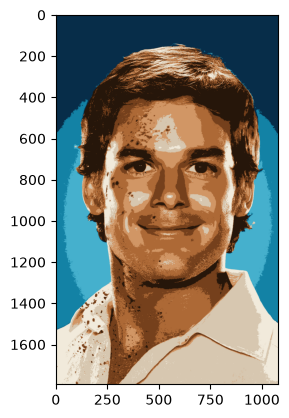

In [43]:
img_q=color_quantization(img,k=9)
plt.imshow(img_q)
plt.show()

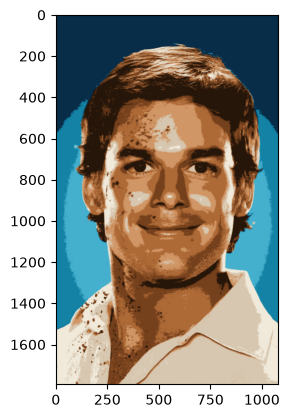

In [44]:
blurred =cv2.bilateralFilter(img_q,d=7,sigmaColor=200,sigmaSpace=200)
plt.imshow(blurred)
plt.show()

cartoon

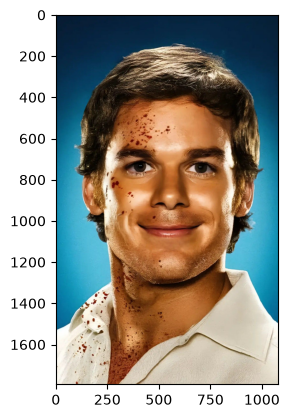

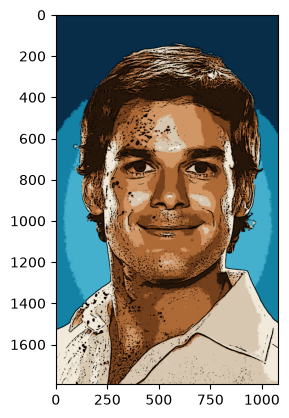

array([[[  7,  45,  73],
        [  7,  45,  73],
        [  7,  45,  73],
        ...,
        [  7,  45,  73],
        [  7,  45,  73],
        [  7,  45,  73]],

       [[  7,  45,  73],
        [  7,  45,  73],
        [  7,  45,  73],
        ...,
        [  7,  45,  73],
        [  7,  45,  73],
        [  7,  45,  73]],

       [[  7,  45,  73],
        [  7,  45,  73],
        [  7,  45,  73],
        ...,
        [  7,  45,  73],
        [  7,  45,  73],
        [  7,  45,  73]],

       ...,

       [[241, 234, 219],
        [241, 234, 219],
        [241, 234, 219],
        ...,
        [217, 201, 179],
        [219, 204, 183],
        [218, 203, 181]],

       [[241, 234, 219],
        [241, 234, 219],
        [241, 234, 219],
        ...,
        [218, 203, 181],
        [221, 207, 186],
        [220, 205, 184]],

       [[241, 234, 219],
        [241, 234, 219],
        [241, 234, 219],
        ...,
        [218, 203, 181],
        [221, 207, 186],
        [220, 205, 184]]

In [45]:
def cartoon(blurred):
    c=cv2.bitwise_and(blurred,blurred,mask=edges)
    
    plt.imshow(og_img)
    plt.show()

    plt.imshow(c)
    plt.show()

    return c
cartoon(blurred)